# Modeling

In this notebook, we will focus on clustering models to segment our customers based on their purchasing behavior. We will explore K-means and DBSCAN algorithms, evaluate their performance, and visualize the results using PCA.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# Set visualisation style
sns.set(style='whitegrid')

In [2]:
# Load the processed RFM scaled data
data = pd.read_csv('../data/processed/rfm_scaled.csv')
print(f"Data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Data shape: (3949, 4)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


,CustomerID,Recency,Frequency,Monetary
0,12346.0,2.210736,-0.777296,-1.050747
1,12348.0,-0.238759,-0.401135,1.157604
2,12349.0,-0.785260,0.143651,1.108835
3,12350.0,2.054593,-0.582730,-0.639855
4,12352.0,-0.619358,0.429015,0.848168


## K-means Clustering

We will start with K-means clustering. First, we need to determine the optimal number of clusters using the Elbow method.

Data to cluster shape: (3949, 3)
Mean values: Recency      0.0
Frequency    0.0
Monetary     0.0
dtype: float64


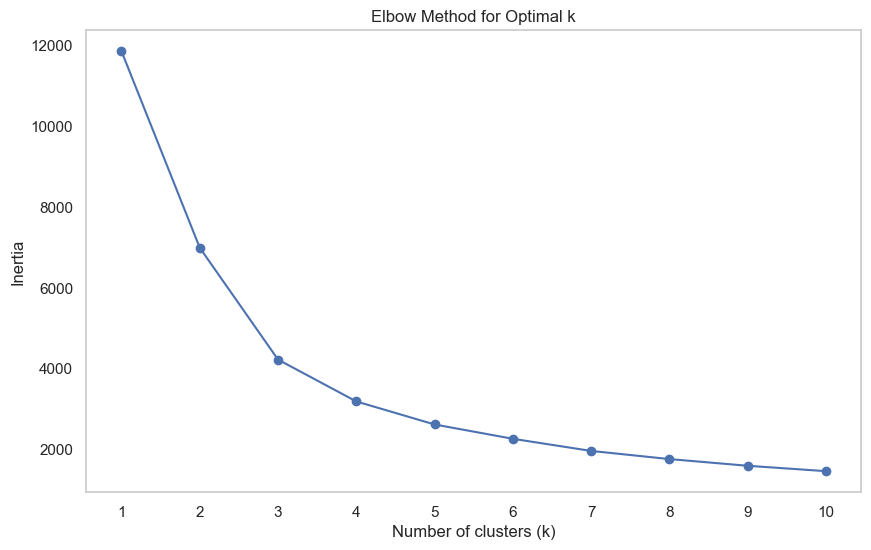

In [3]:
# Extract only numeric columns for scaling (exclude CustomerID)
numeric_data = data[['Recency', 'Frequency', 'Monetary']]

# The data is already scaled, but let's verify
print(f"Data to cluster shape: {numeric_data.shape}")
print(f"Mean values: {numeric_data.mean().round(4)}")

# Determine the optimal number of clusters using Elbow method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(numeric_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid()
plt.show()

From the elbow curve, we can visually inspect the point where the inertia starts to decrease at a slower rate. This will help us choose the optimal number of clusters.

In [4]:
# Fit K-means with the optimal number of clusters
optimal_k = 4  # From the elbow curve analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(numeric_data)

# Add cluster labels to the original data
data['Cluster'] = clusters
print(f"Cluster distribution:")
print(data['Cluster'].value_counts().sort_index())
data.head()

Cluster distribution:
Cluster
0    1002
1     778
2    2046
3     123
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,2.210736,-0.777296,-1.050747,0
1,12348.0,-0.238759,-0.401135,1.157604,1
2,12349.0,-0.785260,0.143651,1.108835,1
3,12350.0,2.054593,-0.582730,-0.639855,0
4,12352.0,-0.619358,0.429015,0.848168,1


## DBSCAN Clustering

Next, we will apply the DBSCAN algorithm for clustering. This method is useful for identifying clusters of varying shapes and sizes.

In [5]:
# Fit DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(numeric_data)

# Add DBSCAN cluster labels to the original data
data['DBSCAN_Cluster'] = dbscan_clusters
print(f"DBSCAN cluster distribution:")
print(data['DBSCAN_Cluster'].value_counts().sort_index())
data.head()

DBSCAN cluster distribution:
DBSCAN_Cluster
-1       2
 0    3947
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster,DBSCAN_Cluster
0,12346.0,2.210736,-0.777296,-1.050747,0,0
1,12348.0,-0.238759,-0.401135,1.157604,1,0
2,12349.0,-0.785260,0.143651,1.108835,1,0
3,12350.0,2.054593,-0.582730,-0.639855,0,0
4,12352.0,-0.619358,0.429015,0.848168,1,0


## PCA Visualization

To visualize the clusters, we will use PCA to reduce the dimensionality of the data to 2D.

In [6]:
# PCA transformation on the numeric columns
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_data)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(pca_df.head())

PCA explained variance ratio: [0.63552868 0.24503002]
Total variance explained: 88.06%
       PCA1      PCA2  Cluster
0 -2.192917  1.334891        0
1  0.595105 -0.038523        1
2  1.159891 -0.317868        1
3 -1.740658  1.390475        0
4  1.092154 -0.134701        1


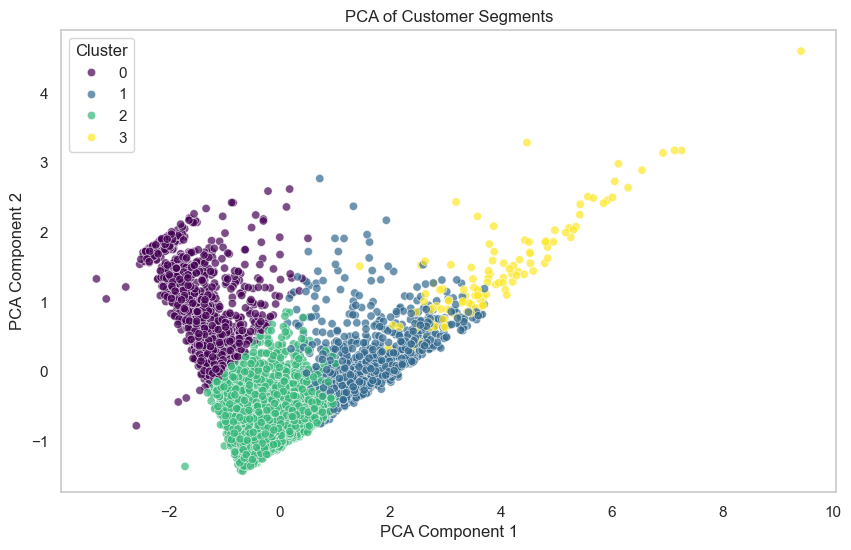

In [7]:
# Plot PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.7)
plt.title('PCA of Customer Segments')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid()
plt.show()

## Conclusion

In this notebook, we applied K-means and DBSCAN clustering algorithms to segment our customers. We visualized the results using PCA, which provided insights into the distribution of customer segments. The next steps will involve generating business insights based on these clusters.